In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pmdarima.arima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from matplotlib.dates import MonthLocator, DateFormatter
from dateutil.relativedelta import relativedelta
from statsmodels.tsa.stattools import acf, pacf
import math
from time import time
from datetime import datetime


# Forecasting and Analyzing the trends of team performances in Premier League Soccer using SARIMA models and Machine Learning models



Rohit Kavuluru

# Introduction

The English Premier League is among the world's most popular sporting leagues. I have followed it for almost a decade. The competition was officially founded in 1992 by the English Football Association and has blossomed into the most competitive soccer league in the world. With any sport, there is a large market for betting in the league. As an avid soccer fan who has played soccer his entire life, I want to know if I can beat the odds using Machine Learning and see if certain trends in match statistics like shots can be used to predict outcomes or team form.

#### Read in the dataset we scraped of premier league matches and perform some data manipulation.

In [218]:
premier_data = pd.read_csv("prem_2020_2023_cleaned.csv")

# Splitting training/testing data to predict last 9 months (or one season)
train_data = premier_data[premier_data["date"] < '2022-06-01']
forecast_data = premier_data[premier_data["date"] > "2022-06-01"]

# Make date a date-time-index
train_data['date'] = pd.to_datetime(train_data['date'])
train_data.set_index('date', inplace=True)

forecast_data['date'] = pd.to_datetime(forecast_data['date'])
forecast_data.set_index('date', inplace=True)





/var/folders/fy/n8v289p11cv8xjhy0t2nrhl80000gn/T/ipykernel_1925/1917517773.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['date'] = pd.to_datetime(train_data['date'])
/var/folders/fy/n8v289p11cv8xjhy0t2nrhl80000gn/T/ipykernel_1925/1917517773.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_data['date'] = pd.to_datetime(forecast_data['date'])


In [194]:
forecast_data.head()

,Unnamed: 0,time,comp,round,day,venue,result,gf,ga,opponent,...,fk,pk,pkatt,season,team,opp_num,hour,venue_num,result_factor,day_code
date,,,,,,,,,,,,,,,,,,,,,
2022-08-05,0,20:00,Premier League,Matchweek 1,Fri,Away,W,2,0,Crystal Palace,...,1.0,0.0,0.0,2023,Arsenal,7,20,0,1,4
2022-08-05,0,20:00,Premier League,Matchweek 1,Fri,Home,L,0,2,Arsenal,...,0.0,0.0,0.0,2023,Crystal Palace,0,20,1,0,4
2022-08-06,0,17:30,Premier League,Matchweek 1,Sat,Home,L,0,1,Chelsea,...,0.0,0.0,0.0,2023,Everton,6,17,1,0,5
2022-08-06,0,15:00,Premier League,Matchweek 1,Sat,Away,L,0,2,Newcastle Utd,...,0.0,0.0,0.0,2023,Nottingham Forest,15,15,0,0,5
2022-08-06,0,15:00,Premier League,Matchweek 1,Sat,Home,W,2,0,Aston Villa,...,0.0,0.0,0.0,2023,Bournemouth,1,15,1,1,5


/var/folders/fy/n8v289p11cv8xjhy0t2nrhl80000gn/T/ipykernel_1925/1435160861.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  monthly_goals = man_utd_data.resample('M').sum()


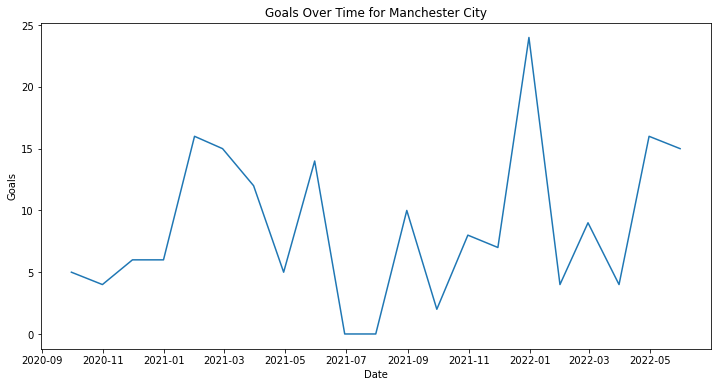

In [202]:
man_city_data = train_data[train_data['team'] == 'Manchester City']

# Group data by month and calculate total goals
monthly_goals = man_city_data.resample('M').sum()

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(monthly_goals.index, monthly_goals['gf'])
plt.title('Goals Over Time for Manchester City')
plt.xlabel('Date')
plt.ylabel('Goals')
plt.show()

###  Now we want to remove the trend 

In [210]:
first_diff = monthly_goals.diff()[1:]

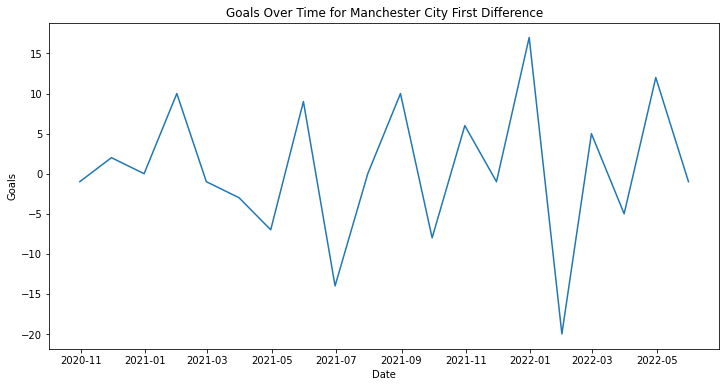

In [208]:

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(first_diff['gf'])
plt.title('Goals Over Time for Manchester City First Difference')
plt.xlabel('Date')
plt.ylabel('Goals')
plt.show()

Taking the first difference the makes our time series centered around 0, which means there isn't a true upwards or downwards trend. This does not remove seasonality however.

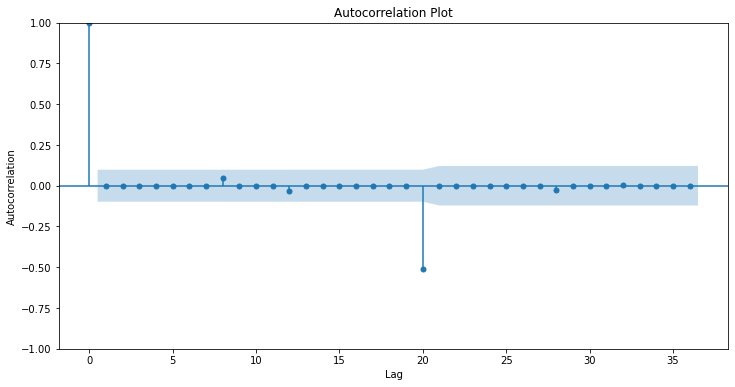

In [233]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

first_diff_1d = np.ravel(first_diff)

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(first_diff_1d, lags=36, ax=ax)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Plot')

plt.show()

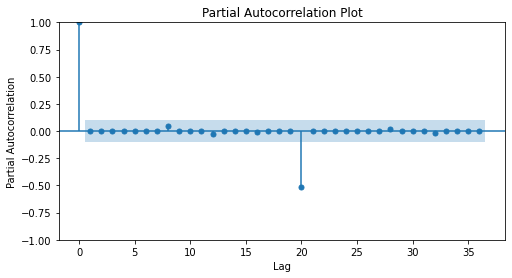

In [225]:
from statsmodels.graphics.tsaplots import plot_pacf

first_diff_1d = np.ravel(first_diff)

fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(first_diff_1d, lags=36
          , ax=ax)
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.title('Partial Autocorrelation Plot')

plt.show()

# Based on PACF we can try to fit a seasonal MA model!

In [238]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set the frequency of the date index
train_data.index = pd.date_range(start=train_data.index[0], periods=len(train_data), freq='M')

# Define the SARIMA model with seasonal component
model = SARIMAX(train_data['gf'], order=(0, 1, 0), seasonal_order=(1, 0, 1,9))

# Fit the model to the training data
model_fit = model.fit()

# Forecast for the next 9 months (one season)
forecast = model_fit.get_forecast(steps=9)

# Extract the forecasted values and confidence intervals
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Print the forecasted values and confidence intervals
print(forecast_values)
print(confidence_intervals)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.01219D+00    |proj g|=  1.73246D-02

At iterate    5    f=  2.01198D+00    |proj g|=  5.47089D-03

At iterate   10    f=  2.01083D+00    |proj g|=  6.81618D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     13     15      1     0     0   1.634D-05   2.011D+00
  F =   2.0107883923120493     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
2147-05-31    2.887401
2147-06-30    3.058944
2147-07-31    3.135847
2

 This problem is unconstrained.


In [239]:
print(model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                  gf   No. Observations:                 1520
Model:             SARIMAX(0, 1, 0)x(1, 0, [1], 9)   Log Likelihood               -3056.398
Date:                             Wed, 14 Jun 2023   AIC                           6118.797
Time:                                     22:30:23   BIC                           6134.774
Sample:                                 09-30-2020   HQIC                          6124.745
                                      - 04-30-2147                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L9        0.4294      0.276      1.555      0.120      -0.112       0.971
ma.S.L9       -0.5000      

In [214]:
predictions = model_fit.forecast(len(forecast_data))
preditions = pd.Series(predictions, index=forecast_data.index)
residuals = forecast_data - predictions

Text(0, 0.5, 'Error')

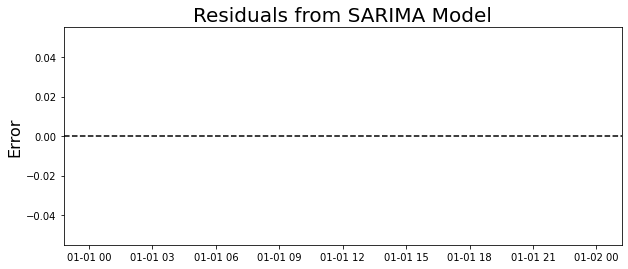

In [215]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0,linestyle='--', color='k')
plt.title('Residuals from SARIMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)

/var/folders/fy/n8v289p11cv8xjhy0t2nrhl80000gn/T/ipykernel_1925/3249710018.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().xaxis.set_major_formatter(plt.FixedFormatter(train_data.index.to_series().dt.strftime("%Y-%b")))


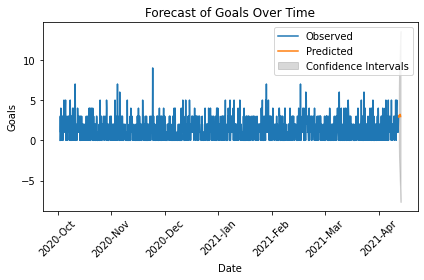

In [217]:
plt.plot(train_data.index, train_data['gf'], label='Observed')

# Plot the predicted values
plt.plot(forecast_values.index, forecast_values, label='Predicted')

# Plot the confidence intervals
plt.fill_between(confidence_intervals.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='gray', alpha=0.3, label='Confidence Intervals')

# Format the x-axis labels with the desired date format
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(plt.FixedFormatter(train_data.index.to_series().dt.strftime("%Y-%b")))

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Goals')
plt.title('Forecast of Goals Over Time')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()